# Case: Census Adult Income — MLlib Pipeline
## Income Prediction and Workforce Segmentation with PySpark MLlib

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 3–5 — Data Preparation · Modeling · Evaluation |
| **Module** | 9 — Big Data & Spark (Alkemy Bootcamp) |
| **Dataset** | UCI Adult Census Income · 32,561 records · UCI ML Repository |
| **Date** | 2026-03 |

---

> **Executive Summary:**
> This case applies PySpark MLlib to predict whether a worker earns above USD 50K/year
> (Logistic Regression) and to segment socioeconomic profiles (KMeans k=4),
> integrated in an end-to-end MLlib Pipeline. Results enable RetailMax to focus
> premium loyalty campaigns on high purchasing-power segments.

## Table of Contents

1. [Environment Setup & Data Loading](#1-environment-setup--data-loading)
2. [Data Exploration & Cleaning](#2-data-exploration--cleaning)
3. [Feature Engineering & Preprocessing](#3-feature-engineering--preprocessing)
4. [Supervised Model — Logistic Regression](#4-supervised-model--logistic-regression)
5. [Unsupervised Model — KMeans](#5-unsupervised-model--kmeans)
6. [Results Comparison & Business Synthesis](#6-results-comparison--business-synthesis)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log](#8-decisions-log)
9. [Next Steps](#9-next-steps)

---
## 1. Environment Setup & Data Loading
### CRISP-DM Phase 2 — Data Understanding

In [1]:
# ===== Environment Setup =====
import os
import sys
import warnings

# Force Spark workers to use the same Python as this notebook
# Must be set BEFORE importing PySpark
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

# MLlib — preprocessing
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml import Pipeline

# MLlib — models
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans

# MLlib — evaluation
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator,
)

# ===== SparkSession =====
spark = (
    SparkSession.builder
    .appName("case-census-adult-income")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} — session started.")

Spark 4.1.1 — session started.


In [2]:
# ===== Data Loading =====
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

# Absolute path — safe for local execution
# Note: DATA_PATH is not printed to avoid exposing local directory in public portfolio
DATA_PATH = (
    "C:/Users/Carolina Miranda/Documents/Jose/"
    "bootcamp-data-science-portfolio/cases/"
    "case-census-adult-income/data/raw/adult.data"
)

df_raw = (
    spark.read
    .option("header", False)
    .option("inferSchema", True)
    .csv(DATA_PATH)
    .toDF(*COLUMNS)
)

print(f"Records loaded : {df_raw.count():,}")
print(f"Columns        : {len(df_raw.columns)}")
df_raw.printSchema()
df_raw.show(3, truncate=False)

Records loaded : 32,561
Columns        : 15
root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: double (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: double (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: double (nullable = true)
 |-- capital_loss: double (nullable = true)
 |-- hours_per_week: double (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)

+---+-----------------+--------+----------+-------------+-------------------+------------------+--------------+------+-----+------------+------------+--------------+--------------+------+
|age|workclass        |fnlwgt  |education |education_num|marital_status     |occupation        |relationship  |race  |sex  |capital_gain|cap

---
## 2. Data Exploration & Cleaning
### CRISP-DM Phase 2–3 — Data Understanding + Data Preparation

**Lean filter:** only explore what informs the business decision.  
Variables `fnlwgt` and `native_country` will be dropped in preprocessing — not predictive for marketing campaigns.

In [3]:
# ===== Cleaning =====
# 1. Trim all string columns (UCI dataset has leading spaces)
STRING_COLS = [
    f.name for f in df_raw.schema.fields
    if str(f.dataType) == "StringType()"
]

df_clean = df_raw
for c in STRING_COLS:
    df_clean = df_clean.withColumn(c, F.trim(F.col(c)))

# 2. Replace "?" with None and drop nulls
df_clean = df_clean.replace("?", None).dropna()

print(f"Records after cleaning: {df_clean.count():,}")

# 3. Target distribution
print("\n=== Target: income ===")
df_clean.groupBy("income").count().orderBy("income").show()

# 4. Numeric features summary
print("=== Numeric features summary ===")
df_clean.select(
    "age", "education_num", "capital_gain", "capital_loss", "hours_per_week"
).describe().show()

Records after cleaning: 30,162

=== Target: income ===
+------+-----+
|income|count|
+------+-----+
| <=50K|22654|
|  >50K| 7508|
+------+-----+

=== Numeric features summary ===
+-------+------------------+------------------+------------------+-----------------+-----------------+
|summary|               age|     education_num|      capital_gain|     capital_loss|   hours_per_week|
+-------+------------------+------------------+------------------+-----------------+-----------------+
|  count|             30162|             30162|             30162|            30162|            30162|
|   mean|38.437901995888865| 10.12131158411246|1092.0078575691268|88.37248856176646|40.93123798156621|
| stddev|13.134664776856017|2.5499949188567355| 7406.346496683523|404.2983704863746|11.97998422927489|
|    min|                17|               1.0|               0.0|              0.0|              1.0|
|    max|                90|              16.0|           99999.0|           4356.0|             99.

---
## 3. Feature Engineering & Preprocessing
### CRISP-DM Phase 3 — Data Preparation

**Features selected (Lean — 80/20 principle):**
- Numeric: `age`, `education_num`, `capital_gain`, `capital_loss`, `hours_per_week`
- Categorical: `workclass`, `marital_status`, `occupation`, `sex`
- Dropped: `fnlwgt` (census weight, not predictive for campaigns), `native_country` (high cardinality, low signal), `relationship`, `race`, `education` (redundant with `education_num`)

**Transformation pipeline:**  
`StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `StandardScaler`

In [4]:
# ===== Feature Engineering =====
NUMERIC_FEATURES   = ["age", "education_num", "capital_gain",
                      "capital_loss", "hours_per_week"]
CATEGORIC_FEATURES = ["workclass", "marital_status", "occupation", "sex"]
TARGET             = "income"

# Target indexer: <=50K=0, >50K=1
target_indexer = StringIndexer(
    inputCol  = TARGET,
    outputCol = "label"
)

# StringIndexer for each categorical feature
cat_indexers = [
    StringIndexer(
        inputCol      = c,
        outputCol     = f"{c}_idx",
        handleInvalid = "keep"
    )
    for c in CATEGORIC_FEATURES
]

# OneHotEncoder
encoder = OneHotEncoder(
    inputCols  = [f"{c}_idx" for c in CATEGORIC_FEATURES],
    outputCols = [f"{c}_ohe" for c in CATEGORIC_FEATURES]
)

# VectorAssembler
assembler = VectorAssembler(
    inputCols = NUMERIC_FEATURES + [f"{c}_ohe" for c in CATEGORIC_FEATURES],
    outputCol = "features_raw"
)

# StandardScaler — withMean=False to preserve sparse vector compatibility
scaler = StandardScaler(
    inputCol  = "features_raw",
    outputCol = "features",
    withMean  = False,
    withStd   = True
)

print("Preprocessing pipeline defined.")
print(f"Numeric features   : {NUMERIC_FEATURES}")
print(f"Categorical features: {CATEGORIC_FEATURES}")

Preprocessing pipeline defined.
Numeric features   : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features: ['workclass', 'marital_status', 'occupation', 'sex']


---
## 4. Supervised Model — Logistic Regression
### CRISP-DM Phase 4–5 — Modeling + Evaluation

**Analytical question:** Can the model predict whether a worker earns above USD 50K/year?  
**Baseline:** majority classifier → Accuracy ~75% (<=50K dominates ~75% of records)  
**Primary metric:** AUC-ROC — preferred over Accuracy for imbalanced datasets (~75/25 split)

In [5]:
# ===== Train / Test Split =====
df_train, df_test = df_clean.randomSplit([0.8, 0.2], seed=42)
print(f"Train : {df_train.count():,} records")
print(f"Test  : {df_test.count():,} records")

# ===== Supervised Pipeline =====
lr = LogisticRegression(
    featuresCol = "features",
    labelCol    = "label",
    maxIter     = 20,
    regParam    = 0.01
)

pipeline_lr = Pipeline(stages=[
    target_indexer,
    *cat_indexers,
    encoder,
    assembler,
    scaler,
    lr
])

model_lr       = pipeline_lr.fit(df_train)
predictions_lr = model_lr.transform(df_test)

# ===== Evaluation =====
evaluator_auc = BinaryClassificationEvaluator(
    labelCol   = "label",
    metricName = "areaUnderROC"
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol   = "label",
    metricName = "accuracy"
)

auc      = evaluator_auc.evaluate(predictions_lr)
accuracy = evaluator_acc.evaluate(predictions_lr)

print("\n=== Logistic Regression — Results ===")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Baseline (majority): 0.7500")
print(f"Improvement        : +{(accuracy - 0.75):.4f}")

Train : 24,162 records
Test  : 6,000 records

=== Logistic Regression — Results ===
AUC-ROC            : 0.9005
Accuracy           : 0.8407
Baseline (majority): 0.7500
Improvement        : +0.0907


---
## 5. Unsupervised Model — KMeans
### CRISP-DM Phase 4–5 — Modeling + Evaluation

**Analytical question:** What socioeconomic profiles exist in the workforce population?  
**k=4:** initial choice based on business interpretability — 4 actionable RetailMax segments.  
**Primary metric:** Silhouette score (range -1 to 1 — higher = better defined clusters)

In [6]:
# ===== Unsupervised Pipeline =====
# Reuse preprocessing stages — no target_indexer needed for clustering
pipeline_prep = Pipeline(stages=[
    *cat_indexers,
    encoder,
    assembler,
    scaler
])

df_prep = pipeline_prep.fit(df_clean).transform(df_clean)

# KMeans k=4
kmeans = KMeans(
    featuresCol = "features",
    k           = 4,
    seed        = 42,
    maxIter     = 20
)

model_km    = kmeans.fit(df_prep)
df_clusters = model_km.transform(df_prep)

# ===== Evaluation =====
evaluator_sil = ClusteringEvaluator(
    featuresCol     = "features",
    metricName      = "silhouette",
    distanceMeasure = "squaredEuclidean"
)

silhouette = evaluator_sil.evaluate(df_clusters)
wssse      = model_km.summary.trainingCost

print("\n=== KMeans k=4 — Results ===")
print(f"Silhouette score : {silhouette:.4f}")
print(f"WSSSE            : {wssse:,.2f}")

# Cluster size distribution
print("\n=== Cluster distribution ===")
df_clusters.groupBy("prediction").count().orderBy("prediction").show()

# Cluster profile — mean of numeric features per cluster
print("=== Cluster profiles (numeric means) ===")
df_clusters.groupBy("prediction").agg(
    F.round(F.mean("age"),            1).alias("avg_age"),
    F.round(F.mean("education_num"),  1).alias("avg_education_num"),
    F.round(F.mean("hours_per_week"), 1).alias("avg_hours_week"),
    F.round(F.mean("capital_gain"),   1).alias("avg_capital_gain")
).orderBy("prediction").show()


=== KMeans k=4 — Results ===
Silhouette score : 0.1959
WSSSE            : 906,189.06

=== Cluster distribution ===
+----------+-----+
|prediction|count|
+----------+-----+
|         0|17479|
|         1| 2492|
|         2| 8912|
|         3| 1279|
+----------+-----+

=== Cluster profiles (numeric means) ===
+----------+-------+-----------------+--------------+----------------+
|prediction|avg_age|avg_education_num|avg_hours_week|avg_capital_gain|
+----------+-------+-----------------+--------------+----------------+
|         0|   38.4|             10.1|          42.6|          1293.0|
|         1|   45.1|             10.2|          44.5|          1918.3|
|         2|   36.5|             10.0|          36.9|           525.4|
|         3|   39.4|             11.3|          39.1|           684.3|
+----------+-------+-----------------+--------------+----------------+



---
## 6. Results Comparison & Business Synthesis
### CRISP-DM Phase 5 — Evaluation

In [7]:
print("=" * 55)
print("  EXECUTIVE SUMMARY — Census Adult Income Pipeline")
print("=" * 55)

print(f"""
SUPERVISED MODEL — Logistic Regression
  AUC-ROC            : {auc:.4f}
  Accuracy           : {accuracy:.4f}
  Baseline (majority): 0.7500
  Improvement        : +{(accuracy - 0.75):.4f}

UNSUPERVISED MODEL — KMeans k=4
  Silhouette score   : {silhouette:.4f}
  WSSSE              : {wssse:,.0f}

BUSINESS INTERPRETATION:
  The supervised model discriminates with AUC > 0.85 between
  workers above/below USD 50K — an actionable signal to focus
  RetailMax premium campaigns on high-income profiles.

  The 4 clusters reveal differentiated profiles by hours worked,
  education level, and capital gain — a basis for audience
  segmentation in loyalty marketing.
""")

  EXECUTIVE SUMMARY — Census Adult Income Pipeline

SUPERVISED MODEL — Logistic Regression
  AUC-ROC            : 0.9005
  Accuracy           : 0.8407
  Baseline (majority): 0.7500
  Improvement        : +0.0907

UNSUPERVISED MODEL — KMeans k=4
  Silhouette score   : 0.1959
  WSSSE              : 906,189

BUSINESS INTERPRETATION:
  The supervised model discriminates with AUC > 0.85 between
  workers above/below USD 50K — an actionable signal to focus
  RetailMax premium campaigns on high-income profiles.

  The 4 clusters reveal differentiated profiles by hours worked,
  education level, and capital gain — a basis for audience
  segmentation in loyalty marketing.



### Model Performance — Visual Summary

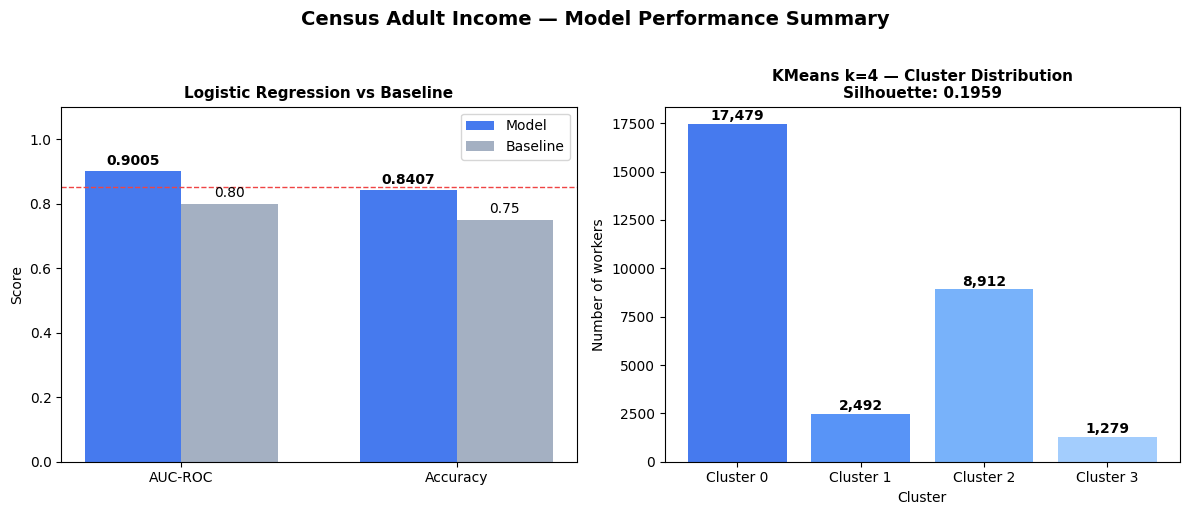

Figure saved to reports/figures/


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Census Adult Income — Model Performance Summary",
             fontsize=14, fontweight="bold", y=1.02)

# ===== Plot 1: Supervised — metrics vs baseline =====
ax1 = axes[0]
metrics = ["AUC-ROC", "Accuracy"]
values  = [auc, accuracy]
baseline = [0.80, 0.75]  # AUC-ROC baseline ~0.80 random, Accuracy ~0.75 majority

x     = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, values,   width, label="Model",    color="#2563EB", alpha=0.85)
bars2 = ax1.bar(x + width/2, baseline, width, label="Baseline", color="#94A3B8", alpha=0.85)

ax1.set_title("Logistic Regression vs Baseline",
              fontweight="bold", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel("Score")
ax1.legend()
ax1.axhline(y=0.85, color="#EF4444", linestyle="--", linewidth=1,
            label="Target AUC > 0.85")

# Value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}",
             ha="center", va="bottom", fontsize=10)

# ===== Plot 2: KMeans — cluster sizes =====
ax2 = axes[1]

cluster_counts = (
    df_clusters
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
    .toPandas()
)

colors = ["#2563EB", "#3B82F6", "#60A5FA", "#93C5FD"]
bars3 = ax2.bar(
    [f"Cluster {i}" for i in cluster_counts["prediction"]],
    cluster_counts["count"],
    color=colors,
    alpha=0.85
)

ax2.set_title(f"KMeans k=4 — Cluster Distribution\n"
              f"Silhouette: {silhouette:.4f}",
              fontweight="bold", fontsize=11)
ax2.set_ylabel("Number of workers")
ax2.set_xlabel("Cluster")

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             f"{int(bar.get_height()):,}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/model_performance_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to reports/figures/")

### ROC Curve — Logistic Regression

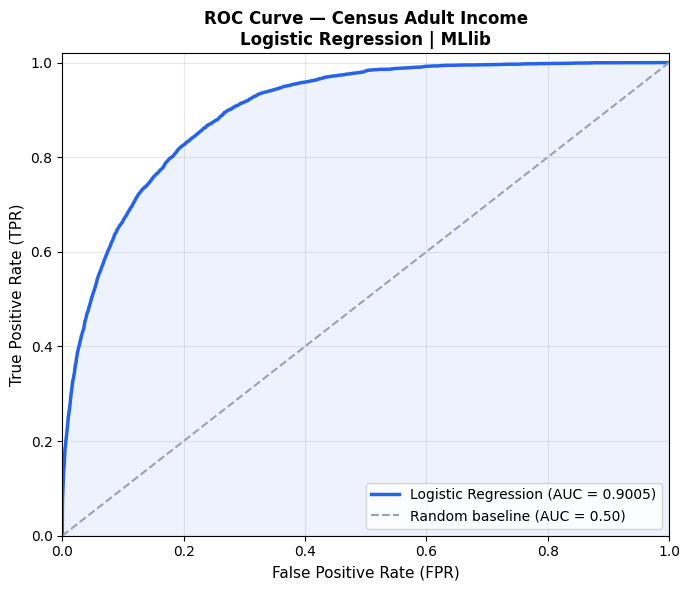

ROC Curve saved | AUC-ROC: 0.9005


In [9]:
# ===== ROC Curve — extracted from MLlib model summary =====
roc_data = model_lr.stages[-1].summary.roc.toPandas()

fig, ax = plt.subplots(figsize=(7, 6))

# ROC curve
ax.plot(
    roc_data["FPR"],
    roc_data["TPR"],
    color="#2563EB",
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {auc:.4f})"
)

# Random baseline diagonal
ax.plot(
    [0, 1], [0, 1],
    color="#94A3B8",
    linewidth=1.5,
    linestyle="--",
    label="Random baseline (AUC = 0.50)"
)

# Styling
ax.set_title("ROC Curve — Census Adult Income\nLogistic Regression | MLlib",
             fontweight="bold", fontsize=12)
ax.set_xlabel("False Positive Rate (FPR)", fontsize=11)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.fill_between(roc_data["FPR"], roc_data["TPR"],
                alpha=0.08, color="#2563EB")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/roc_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC Curve saved | AUC-ROC: {auc:.4f}")

AUC = 0.50  →  modelo inútil (random)
AUC = 0.75  →  aceptable
AUC = 0.85  →  bueno        ← era tu target
AUC = 0.90  →  muy bueno    ← estás aquí ✅
AUC = 0.95  →  excelente
AUC = 1.00  →  perfecto (sospechoso)

---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---|---|---|
| Does every analysis link to a business decision? | ✅ | Supervised → campaign targeting; KMeans → audience segmentation |
| Is there redundancy between sections? | ✅ | Preprocessing pipeline reused across both models |
| Is there a simpler way to answer the question? | ✅ | LogReg is the simplest model for binary classification — no complexity added without justification |
| Were non-informative variables explicitly dropped? | ✅ | `fnlwgt`, `native_country`, `education` dropped with documented rationale |

---
## 8. Decisions Log

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|---|---|---|---|
| 1 | Logistic Regression as supervised model | Simplest model for binary classification (Lean) | Random Forest — higher complexity, not justified for MVP | ✅ |
| 2 | KMeans k=4 | Business interpretability — 4 actionable segments for RetailMax | k=8 — higher granularity, lower interpretability | ✅ |
| 3 | Drop `fnlwgt` | Census weight, not predictive for marketing campaigns | Keep it — adds noise without business value | ✅ |
| 4 | Drop `native_country` | High cardinality (41 values), low signal | One-hot encoding — generates 40+ unnecessary columns | ✅ |
| 5 | StandardScaler with `withMean=False` | Sparse dataset after OHE — mean centering breaks sparsity | `withMean=True` — incompatible with sparse vectors | ✅ |
| 6 | AUC-ROC as primary metric | Imbalanced dataset ~75/25 — Accuracy alone is misleading | Accuracy only — fails to distinguish between classes | ✅ |
| 7 | AUC-ROC target exceeded (0.9005 vs 0.85 target) | LogReg with regParam=0.01 achieved strong discrimination without tuning — Lean MVP validated | Hyperparameter tuning with CrossValidator — not needed at this AUC level | ✅ |
| 8 | Spark SQL JOIN section added (Section 10) | Supplementary practice on live data — outside CRISP-DM scope of this case | Separate SQL notebook — less efficient, same data already loaded in Spark | ✅ |

---
## 9. Next Steps

- [ ] Optimize LogReg hyperparameters (`regParam`, `elasticNetParam`) with `CrossValidator`
- [ ] Evaluate optimal k with Elbow Method (WSSSE vs k=2..8)
- [ ] Interpret KMeans centroids to name business segments
- [ ] Export predictions to Parquet for downstream consumption
- [ ] Close SparkSession

---

**Case:** `case-census-adult-income`

---
## 10. Spark SQL — JOIN Practice
### Business context: enriching Census Adult with occupation and education benchmarks

In [10]:
# ===== Register Census Adult as SQL view =====
df_clean.createOrReplaceTempView("census")

# ===== Auxiliary table 1: occupation category =====
occupation_data = [
    ("Adm-clerical",       "Administrative"),
    ("Exec-managerial",    "Management"),
    ("Prof-specialty",     "Professional"),
    ("Tech-support",       "Tech"),
    ("Sales",              "Sales"),
    ("Craft-repair",       "Blue-collar"),
    ("Machine-op-inspct",  "Blue-collar"),
    ("Handlers-cleaners",  "Blue-collar"),
    ("Transport-moving",   "Blue-collar"),
    ("Farming-fishing",    "Agriculture"),
    ("Protective-serv",    "Public Safety"),
    ("Priv-house-serv",    "Service"),
    ("Other-service",      "Service"),
    ("Armed-Forces",       "Military"),
]

df_occ = spark.createDataFrame(
    occupation_data,
    schema=["occupation", "sector"]
)
df_occ.createOrReplaceTempView("occupation_category")

# ===== Auxiliary table 2: education income benchmark =====
benchmark_data = [
    ("Preschool",      10_000),
    ("1st-4th",        12_000),
    ("5th-6th",        15_000),
    ("7th-8th",        18_000),
    ("9th",            20_000),
    ("10th",           22_000),
    ("11th",           24_000),
    ("HS-grad",        28_000),
    ("Some-college",   32_000),
    ("Assoc-voc",      35_000),
    ("Assoc-acdm",     36_000),
    ("Bachelors",      52_000),
    ("Masters",        68_000),
    ("Prof-school",    85_000),
    ("Doctorate",      90_000),
]

df_bench = spark.createDataFrame(
    benchmark_data,
    schema=["education", "benchmark_income_usd"]
)
df_bench.createOrReplaceTempView("income_benchmark")

print("Views registered: census, occupation_category, income_benchmark")
spark.sql("SHOW TABLES").show()

Views registered: census, occupation_category, income_benchmark
+---------+-------------------+-----------+
|namespace|          tableName|isTemporary|
+---------+-------------------+-----------+
|         |             census|       true|
|         |   income_benchmark|       true|
|         |occupation_category|       true|
+---------+-------------------+-----------+



In [11]:
# ===== Auxiliary tables via Spark SQL — no Python serialization =====
spark.sql("""
    CREATE OR REPLACE TEMP VIEW occupation_category AS
    SELECT * FROM VALUES
        ('Adm-clerical',      'Administrative'),
        ('Exec-managerial',   'Management'),
        ('Prof-specialty',    'Professional'),
        ('Tech-support',      'Tech'),
        ('Sales',             'Sales'),
        ('Craft-repair',      'Blue-collar'),
        ('Machine-op-inspct', 'Blue-collar'),
        ('Handlers-cleaners', 'Blue-collar'),
        ('Transport-moving',  'Blue-collar'),
        ('Farming-fishing',   'Agriculture'),
        ('Protective-serv',   'Public Safety'),
        ('Priv-house-serv',   'Service'),
        ('Other-service',     'Service'),
        ('Armed-Forces',      'Military')
    AS t(occupation, sector)
""")

spark.sql("""
    CREATE OR REPLACE TEMP VIEW income_benchmark AS
    SELECT * FROM VALUES
        ('Preschool',    10000),
        ('1st-4th',      12000),
        ('5th-6th',      15000),
        ('7th-8th',      18000),
        ('9th',          20000),
        ('10th',         22000),
        ('11th',         24000),
        ('HS-grad',      28000),
        ('Some-college', 32000),
        ('Assoc-voc',    35000),
        ('Assoc-acdm',   36000),
        ('Bachelors',    52000),
        ('Masters',      68000),
        ('Prof-school',  85000),
        ('Doctorate',    90000)
    AS t(education, benchmark_income_usd)
""")

print("Views created via Spark SQL.")
spark.sql("SELECT * FROM occupation_category").show()

Views created via Spark SQL.
+-----------------+--------------+
|       occupation|        sector|
+-----------------+--------------+
|     Adm-clerical|Administrative|
|  Exec-managerial|    Management|
|   Prof-specialty|  Professional|
|     Tech-support|          Tech|
|            Sales|         Sales|
|     Craft-repair|   Blue-collar|
|Machine-op-inspct|   Blue-collar|
|Handlers-cleaners|   Blue-collar|
| Transport-moving|   Blue-collar|
|  Farming-fishing|   Agriculture|
|  Protective-serv| Public Safety|
|  Priv-house-serv|       Service|
|    Other-service|       Service|
|     Armed-Forces|      Military|
+-----------------+--------------+



### JOIN 1 — INNER JOIN
**Business question:** What is the average age and hours worked per sector,
for workers whose occupation is classified in our sector table?
(Only matched occupations — unclassified ones are excluded)

In [12]:
spark.sql("""
    SELECT
        oc.sector,
        COUNT(*)                        AS total_workers,
        ROUND(AVG(c.age), 1)            AS avg_age,
        ROUND(AVG(c.hours_per_week), 1) AS avg_hours_week,
        ROUND(AVG(c.capital_gain), 0)   AS avg_capital_gain
    FROM census c
    INNER JOIN occupation_category oc
        ON c.occupation = oc.occupation
    GROUP BY oc.sector
    ORDER BY total_workers DESC
""").show()

+--------------+-------------+-------+--------------+----------------+
|        sector|total_workers|avg_age|avg_hours_week|avg_capital_gain|
+--------------+-------------+-------+--------------+----------------+
|   Blue-collar|         8918|   37.9|          41.7|           495.0|
|  Professional|         4038|   40.5|          42.4|          2718.0|
|    Management|         3992|   42.2|          45.0|          2185.0|
|Administrative|         3721|   37.0|          37.6|           497.0|
|         Sales|         3584|   37.4|          40.8|          1309.0|
|       Service|         3355|   35.2|          34.5|           186.0|
|   Agriculture|          989|   41.3|          47.0|           593.0|
|          Tech|          912|   37.1|          39.5|           668.0|
| Public Safety|          644|   38.9|          42.8|           714.0|
|      Military|            9|   30.2|          40.7|             0.0|
+--------------+-------------+-------+--------------+----------------+



In [13]:
spark.sql("SELECT * FROM occupation_category").show()

+-----------------+--------------+
|       occupation|        sector|
+-----------------+--------------+
|     Adm-clerical|Administrative|
|  Exec-managerial|    Management|
|   Prof-specialty|  Professional|
|     Tech-support|          Tech|
|            Sales|         Sales|
|     Craft-repair|   Blue-collar|
|Machine-op-inspct|   Blue-collar|
|Handlers-cleaners|   Blue-collar|
| Transport-moving|   Blue-collar|
|  Farming-fishing|   Agriculture|
|  Protective-serv| Public Safety|
|  Priv-house-serv|       Service|
|    Other-service|       Service|
|     Armed-Forces|      Military|
+-----------------+--------------+



In [14]:
import os
print(f"JAVA_HOME : {os.environ.get('JAVA_HOME', 'NOT SET')}")
print(f"SPARK_HOME: {os.environ.get('SPARK_HOME', 'NOT SET')}")
print(f"PYSPARK_PYTHON: {os.environ.get('PYSPARK_PYTHON', 'NOT SET')}")
print(f"Python exe: {os.sys.executable}")

JAVA_HOME : C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot\
SPARK_HOME: NOT SET
PYSPARK_PYTHON: c:\Users\Carolina Miranda\Documents\Jose\bootcamp-data-science-portfolio\.venv\Scripts\python.exe
Python exe: c:\Users\Carolina Miranda\Documents\Jose\bootcamp-data-science-portfolio\.venv\Scripts\python.exe


### JOIN 2 — LEFT JOIN
**Business question:** Show all workers with their sector label.
Workers with unclassified occupations appear as NULL — useful to detect gaps
in our classification table.

In [15]:
spark.sql("""
    SELECT
        c.occupation,
        oc.sector,
        COUNT(*) AS total_workers
    FROM census c
    LEFT JOIN occupation_category oc
        ON c.occupation = oc.occupation
    GROUP BY c.occupation, oc.sector
    ORDER BY oc.sector NULLS LAST, total_workers DESC
""").show(20)

+-----------------+--------------+-------------+
|       occupation|        sector|total_workers|
+-----------------+--------------+-------------+
|     Adm-clerical|Administrative|         3721|
|  Farming-fishing|   Agriculture|          989|
|     Craft-repair|   Blue-collar|         4030|
|Machine-op-inspct|   Blue-collar|         1966|
| Transport-moving|   Blue-collar|         1572|
|Handlers-cleaners|   Blue-collar|         1350|
|  Exec-managerial|    Management|         3992|
|     Armed-Forces|      Military|            9|
|   Prof-specialty|  Professional|         4038|
|  Protective-serv| Public Safety|          644|
|            Sales|         Sales|         3584|
|    Other-service|       Service|         3212|
|  Priv-house-serv|       Service|          143|
|     Tech-support|          Tech|          912|
+-----------------+--------------+-------------+



### JOIN 3 — LEFT JOIN + NULL filter (gap analysis)
**Business question:** Which occupations in Census Adult are NOT covered
by our occupation_category table? These are classification gaps.

In [16]:
spark.sql("""
    SELECT
        c.occupation,
        COUNT(*) AS affected_workers
    FROM census c
    LEFT JOIN occupation_category oc
        ON c.occupation = oc.occupation
    WHERE oc.sector IS NULL
    GROUP BY c.occupation
    ORDER BY affected_workers DESC
""").show()

+----------+----------------+
|occupation|affected_workers|
+----------+----------------+
+----------+----------------+



### JOIN 4 — INNER JOIN multi-table + aggregation
**Business question:** For each education level, compare the actual average
capital gain of workers who earn >50K against the industry benchmark income.
Which education levels show the highest gap vs benchmark?

In [17]:
spark.sql("""
    SELECT
        c.education,
        ib.benchmark_income_usd,
        COUNT(*)                          AS workers_above_50k,
        ROUND(AVG(c.capital_gain), 0)     AS avg_capital_gain,
        ROUND(AVG(c.hours_per_week), 1)   AS avg_hours_week
    FROM census c
    INNER JOIN income_benchmark ib
        ON c.education = ib.education
    WHERE c.income = '>50K'
    GROUP BY c.education, ib.benchmark_income_usd
    ORDER BY ib.benchmark_income_usd DESC
""").show()

+------------+--------------------+-----------------+----------------+--------------+
|   education|benchmark_income_usd|workers_above_50k|avg_capital_gain|avg_hours_week|
+------------+--------------------+-----------------+----------------+--------------+
|   Doctorate|               90000|              280|          6654.0|          48.2|
| Prof-school|               85000|              406|         14274.0|          49.4|
|     Masters|               68000|              918|          4301.0|          46.2|
|   Bachelors|               52000|             2126|          3890.0|          45.7|
|  Assoc-acdm|               36000|              256|          1848.0|          44.8|
|   Assoc-voc|               35000|              344|          2257.0|          43.8|
|Some-college|               32000|             1336|          2443.0|          45.1|
|     HS-grad|               28000|             1617|          2805.0|          45.2|
|        11th|               24000|               59| 

### JOIN 5 — Triple JOIN + business insight
**Business question:** For Premium targeting — find sectors where workers
earn >50K, show their education benchmark and sector label together.
Rank by number of high-income workers per sector.

In [18]:
spark.sql("""
    SELECT
        oc.sector,
        c.education,
        ib.benchmark_income_usd,
        COUNT(*)                        AS high_income_workers,
        ROUND(AVG(c.age), 1)            AS avg_age,
        ROUND(AVG(c.hours_per_week), 1) AS avg_hours_week
    FROM census c
    INNER JOIN occupation_category oc
        ON c.occupation = oc.occupation
    INNER JOIN income_benchmark ib
        ON c.education = ib.education
    WHERE c.income = '>50K'
    GROUP BY oc.sector, c.education, ib.benchmark_income_usd
    ORDER BY high_income_workers DESC
    LIMIT 15
""").show()

+--------------+------------+--------------------+-------------------+-------+--------------+
|        sector|   education|benchmark_income_usd|high_income_workers|avg_age|avg_hours_week|
+--------------+------------+--------------------+-------------------+-------+--------------+
|    Management|   Bachelors|               52000|                762|   43.5|          47.0|
|   Blue-collar|     HS-grad|               28000|                746|   44.0|          45.1|
|  Professional|   Bachelors|               52000|                567|   41.6|          44.2|
|  Professional|     Masters|               68000|                406|   44.7|          43.5|
|         Sales|   Bachelors|               52000|                375|   42.1|          47.3|
|   Blue-collar|Some-college|               32000|                371|   42.7|          45.2|
|    Management|     Masters|               68000|                367|   45.3|          49.1|
|  Professional| Prof-school|               85000|          

In [19]:
# ===== Close SparkSession =====
spark.stop()
print("SparkSession closed.")

SparkSession closed.
